# Hands-On Lab — Bias-Variance & Diagnosing Model Fit
**Week 4 — Day 3 | BinX Tech AI & ML Internship**

---

## Objective

In the learning notebook I built the diagnostic toolkit:
underfitting vs overfitting, the bias-variance trade-off,
regularization, and data leakage.

In this lab I apply the full workflow on the Student Performance
dataset — deliberately breaking the model in both directions,
diagnosing each case from the numbers, fixing it, and proving
the fix worked with score evidence.

**Dataset:** Student Performance (2,392 students, 5-class grade prediction)  

---

## Step 1 — Import Libraries

In [237]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, r2_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

SEED = 42

## Step 2 — Load & Inspect the Data

The Student Performance dataset contains 2,392 students with
demographic, behavioral, and academic features. The target is
`GradeClass` — a 5-class label where 0 = A (best) and 4 = F (worst).

I drop `StudentID` because it's an identifier, not a feature.
I use **weighted F1** throughout — class 4 (grade F) accounts for
50.6% of the data, making the class distribution highly unequal.

In [238]:
# Load the Student Performance dataset
df = pd.read_csv(
    "../../Week1/mini_project/Data/Student_performance_data _.csv"
)

# StudentID is only an identifier, so it should not be used as a feature
df = df.drop(columns=["StudentID"])

# Separate features (X) from the target (y)
X = df.drop(columns=["GradeClass"])
y = df["GradeClass"].astype(int)

# Basic dataset information
print(f"Shape: {df.shape[0]} rows, {X.shape[1]} features")

# Check the class distribution
print("\nTarget distribution:")

dist = y.value_counts().sort_index()

for grade, count in dist.items():
    label = ["A", "B", "C", "D", "F"][grade]
    percentage = count / len(y)

    print(
        f"  Class {grade} (Grade {label}): "
        f"{count:>4} students ({percentage:.1%})"
    )

Shape: 2392 rows, 13 features

Target distribution:
  Class 0 (Grade A):  107 students (4.5%)
  Class 1 (Grade B):  269 students (11.2%)
  Class 2 (Grade C):  391 students (16.3%)
  Class 3 (Grade D):  414 students (17.3%)
  Class 4 (Grade F): 1211 students (50.6%)


## Step 3 — Three Way Split

Same discipline from Day 1: the test set is locked before any
model experimentation.

- **Training set (60%)** → used to fit the models.
- **Validation set (20%)** → used for all experiments, diagnosis,
  and model selection.
- **Test set (20%)** → kept untouched until the final evaluation.

I use stratification to preserve the original class distribution
across all three sets.

In [239]:
# Lock 20% as the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Split the remaining 80% into 60% training and 20% validation
# 0.25 × 0.80 = 0.20 of the original dataset
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp
)

# Check the final split sizes
print(f"Training:   {X_tr.shape[0]} rows  (60%)")
print(f"Validation: {X_val.shape[0]} rows  (20%)  => experiments")
print(f"Test:       {X_test.shape[0]} rows  (20%)  => locked ")

Training:   1434 rows  (60%)
Validation: 479 rows  (20%)  => experiments
Test:       479 rows  (20%)  => locked 


## Step 4 — Experiment 1: Deliberate Overfitting

**Hypothesis:** A Decision Tree with `max_depth=None` is likely to
fit the training data extremely closely, leading to a much higher
Training F1 than Validation F1.

I will use the train-validation gap as evidence of overfitting.

In [240]:
# Train an unconstrained tree
overfit_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

overfit_model.fit(X_tr, y_tr)

# Make predictions on both sets
train_pred_of = overfit_model.predict(X_tr)
val_pred_of = overfit_model.predict(X_val)

# Calculate F1 scores
train_f1_of = f1_score(
    y_tr,
    train_pred_of,
    average="weighted"
)

val_f1_of = f1_score(
    y_val,
    val_pred_of,
    average="weighted"
)

# Measure the train-validation gap
gap_of = train_f1_of - val_f1_of

print(f"Train F1:      {train_f1_of:.3f}")
print(f"Validation F1: {val_f1_of:.3f}")
print(f"Gap:           {gap_of:.3f}")

Train F1:      1.000
Validation F1: 0.832
Gap:           0.168


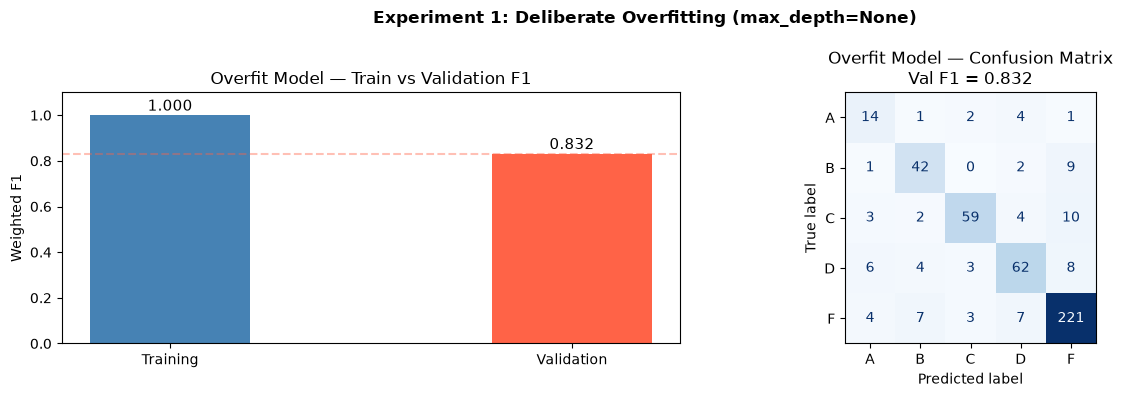

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Train vs validation scores
scores_of = pd.DataFrame({
    "Set": ["Training", "Validation"],
    "F1": [train_f1_of, val_f1_of]
})

axes[0].bar(
    scores_of["Set"],
    scores_of["F1"],
    color=["steelblue", "tomato"],
    width=0.4
)

axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Weighted F1")
axes[0].set_title("Overfit Model — Train vs Validation F1")

# Add score labels
for i, value in enumerate(scores_of["F1"]):
    axes[0].text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontsize=11
    )

axes[0].axhline(
    val_f1_of,
    color="tomato",
    linestyle="--",
    alpha=0.4
)


# Validation confusion matrix
cm_of = confusion_matrix(y_val, val_pred_of)

ConfusionMatrixDisplay(
    cm_of,
    display_labels=["A", "B", "C", "D", "F"]
).plot(
    ax=axes[1],
    colorbar=False,
    cmap="Blues"
)

axes[1].set_title(
    f"Overfit Model — Confusion Matrix\nVal F1 = {val_f1_of:.3f}"
)

plt.suptitle(
    "Experiment 1: Deliberate Overfitting (max_depth=None)",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Diagnosis: Overfitting — High Variance**

Evidence:

- Train F1 = 1.000 — the tree fits the training data perfectly.
- Val F1   = 0.832 — performance drops on unseen data.
- Gap      = 0.168 — a clear train-validation performance gap.

The confusion matrix shows that the model still makes
classification errors on validation, even though it achieved
perfect performance on the training set.

**Why:** With `max_depth=None`, the tree can keep creating splits
until it fits the training data very closely. This allows the model
to learn noise and sample-specific patterns instead of only the
general patterns.

**Fix:** Constrain the tree's complexity.

>This is a high-variance model: its performance depends strongly
on the training data it sees, so it generalizes less reliably to
unseen samples.

## Step 5 — Experiment 2: Deliberate Underfitting

**Hypothesis:** `max_depth=1` allows the tree to make only one split,
which is far too simple for a 5-class problem with 12 features.

Both training and validation scores should be low, with a small
train-validation gap.

In [242]:
# Build a deliberately simple Decision Tree
underfit_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=SEED
)

# Train the model
underfit_model.fit(X_tr, y_tr)

# Calculate weighted F1 on training and validation sets
train_f1_uf = f1_score(
    y_tr,
    underfit_model.predict(X_tr),
    average="weighted"
)

val_f1_uf = f1_score(
    y_val,
    underfit_model.predict(X_val),
    average="weighted"
)

# Measure the train-validation gap
gap_uf = train_f1_uf - val_f1_uf

print(f"Train F1:      {train_f1_uf:.3f}")
print(f"Validation F1: {val_f1_uf:.3f}")
print(f"Gap:           {gap_uf:.3f}")

Train F1:      0.576
Validation F1: 0.565
Gap:           0.011


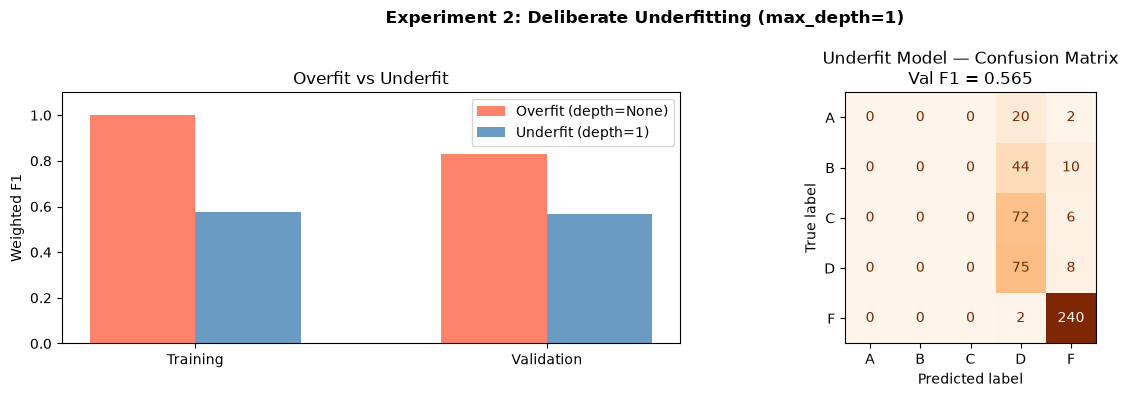

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Compare training and validation F1 for both models
labels = ["Training", "Validation"]

overfit_scores = [train_f1_of, val_f1_of]
underfit_scores = [train_f1_uf, val_f1_uf]

x = np.arange(len(labels))
width = 0.3

axes[0].bar(
    x - width / 2,
    overfit_scores,
    width,
    label="Overfit (depth=None)",
    color="tomato",
    alpha=0.8
)

axes[0].bar(
    x + width / 2,
    underfit_scores,
    width,
    label="Underfit (depth=1)",
    color="steelblue",
    alpha=0.8
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Weighted F1")
axes[0].set_title("Overfit vs Underfit")
axes[0].legend()

# Show where the underfit model makes mistakes
cm_uf = confusion_matrix(
    y_val,
    underfit_model.predict(X_val)
)

ConfusionMatrixDisplay(
    cm_uf,
    display_labels=["A", "B", "C", "D", "F"]
).plot(
    ax=axes[1],
    colorbar=False,
    cmap="Oranges"
)

axes[1].set_title(
    f"Underfit Model — Confusion Matrix\n"
    f"Val F1 = {val_f1_uf:.3f}"
)

plt.suptitle(
    "Experiment 2: Deliberate Underfitting (max_depth=1)",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Diagnosis: Underfitting — High Bias**

Evidence:

- Train F1 = 0.576 — poor performance even on training data
- Val F1   = 0.565 — nearly identical to training
- Gap      = 0.011 — small gap, but both scores are low

The confusion matrix shows that the model struggles to separate
the five grade classes. Because the tree has only one split,
its capacity is too limited to capture the relationships between
the 12 features and the target.

**This is the key distinction:** the small gap is not evidence
of a good model — it means the model is performing similarly poorly
on both training and validation data.

**Diagnosis:** High bias caused by insufficient model complexity.

**Fix:** increase model complexity.

## Step 6 — Experiment 3: Fixing Overfitting

**Hypothesis:** Reducing `max_depth` to 5 should reduce the
train-validation gap and improve validation performance.

The training score dropping is expected — and desirable.
The goal is better generalization, not memorization.

In [244]:
# Build a constrained tree to reduce overfitting
fixed_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)

# Train the model
fixed_model.fit(X_tr, y_tr)

# Evaluate on training and validation sets
train_f1_fx = f1_score(
    y_tr,
    fixed_model.predict(X_tr),
    average="weighted"
)

val_f1_fx = f1_score(
    y_val,
    fixed_model.predict(X_val),
    average="weighted"
)

# Calculate the train-validation gap
gap_fx = train_f1_fx - val_f1_fx

# Compare the original overfit model with the fixed model
print("Before (max_depth=None):")
print(
    f"  Train F1: {train_f1_of:.3f} | "
    f"Val F1: {val_f1_of:.3f} | "
    f"Gap: {gap_of:.3f}"
)

print("\nAfter (max_depth=5):")
print(
    f"  Train F1: {train_f1_fx:.3f} | "
    f"Val F1: {val_f1_fx:.3f} | "
    f"Gap: {gap_fx:.3f}"
)

print(f"\nGap reduced by: {gap_of - gap_fx:.3f}")
print(f"Val F1 change: {val_f1_fx - val_f1_of:+.3f}")

Before (max_depth=None):
  Train F1: 1.000 | Val F1: 0.832 | Gap: 0.168

After (max_depth=5):
  Train F1: 0.942 | Val F1: 0.898 | Gap: 0.044

Gap reduced by: 0.124
Val F1 change: +0.067


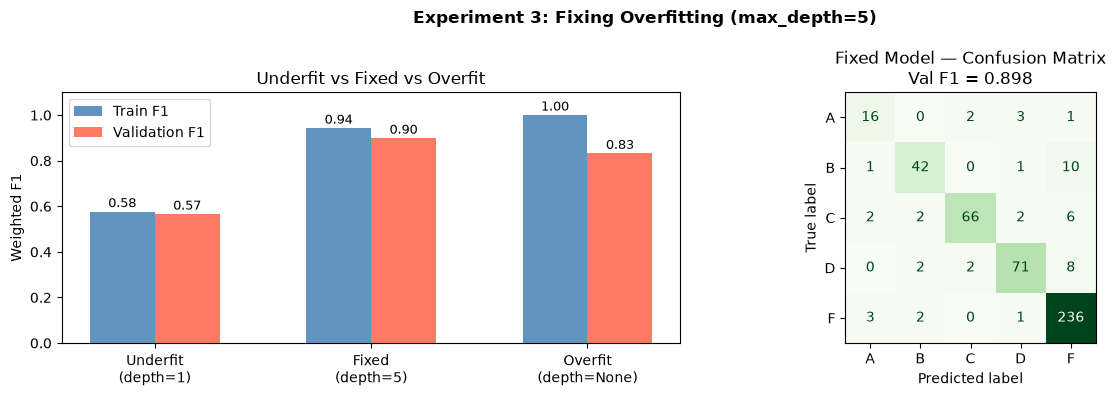

In [245]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Compare the three models
model_names = [
    "Underfit\n(depth=1)",
    "Fixed\n(depth=5)",
    "Overfit\n(depth=None)"
]

train_scores = [
    train_f1_uf,
    train_f1_fx,
    train_f1_of
]

val_scores = [
    val_f1_uf,
    val_f1_fx,
    val_f1_of
]

x = np.arange(len(model_names))
width = 0.3

# Training F1
axes[0].bar(
    x - width / 2,
    train_scores,
    width,
    label="Train F1",
    color="steelblue",
    alpha=0.85
)

# Validation F1
axes[0].bar(
    x + width / 2,
    val_scores,
    width,
    label="Validation F1",
    color="tomato",
    alpha=0.85
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Weighted F1")
axes[0].set_title("Underfit vs Fixed vs Overfit")
axes[0].legend()

# Add score labels above each bar
for i, (train_score, val_score) in enumerate(
    zip(train_scores, val_scores)
):
    axes[0].text(
        i - width / 2,
        train_score + 0.02,
        f"{train_score:.2f}",
        ha="center",
        fontsize=9
    )

    axes[0].text(
        i + width / 2,
        val_score + 0.02,
        f"{val_score:.2f}",
        ha="center",
        fontsize=9
    )

# Validation confusion matrix for the fixed model
cm_fx = confusion_matrix(
    y_val,
    fixed_model.predict(X_val)
)

ConfusionMatrixDisplay(
    cm_fx,
    display_labels=["A", "B", "C", "D", "F"]
).plot(
    ax=axes[1],
    colorbar=False,
    cmap="Greens"
)

axes[1].set_title(
    f"Fixed Model — Confusion Matrix\n"
    f"Val F1 = {val_f1_fx:.3f}"
)

plt.suptitle(
    "Experiment 3: Fixing Overfitting (max_depth=5)",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Diagnosis: Overfitting reduced**

Evidence:

- Train F1 dropped: 1.000 → 0.942
- Val F1 improved: 0.832 → 0.898 (+0.066)
- Gap decreased: 0.168 → 0.044

The lower training score is expected because the tree is now less
complex and has less capacity to memorize the training data.

The important result is that validation F1 improved at the same time.
This means the simpler model generalizes better on unseen validation
data.

The confusion matrix gives an additional view of where the fixed model
is still making mistakes across the five grade classes.

**Conclusion:** reducing model complexity successfully reduced
overfitting in this experiment.

> Note: depth=5 looks promising here, but I will test several depth
> values in the next experiment before calling it the final sweet spot.

## Step 7 — Full Complexity Experiment

Testing multiple `max_depth` values to map the bias-variance
trade-off and identify the best validation performance.

The goal is to see how increasing model complexity affects
training F1, validation F1, and the train-validation gap.

In [246]:
# Test different tree depths
depths = [1, 2, 3, 5, 8, 10, 15, None]

results = []

for depth in depths:

    # Build and train a tree with the current depth
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=SEED
    )

    model.fit(X_tr, y_tr)

    # Evaluate on training and validation sets
    train_f1 = f1_score(
        y_tr,
        model.predict(X_tr),
        average="weighted"
    )

    val_f1 = f1_score(
        y_val,
        model.predict(X_val),
        average="weighted"
    )

    # Calculate the train-validation gap
    gap = train_f1 - val_f1

    results.append({
        "max_depth": str(depth),
        "Train F1": round(train_f1, 3),
        "Val F1": round(val_f1, 3),
        "Gap": round(gap, 3)
    })

# Store all results in a DataFrame
df_results = pd.DataFrame(results)

print(df_results.to_string(index=False))

# Find the depth with the highest validation F1
best_idx = df_results["Val F1"].idxmax()
best_depth = df_results.loc[best_idx, "max_depth"]
best_val_f1 = df_results.loc[best_idx, "Val F1"]

print(
    f"\nBest validation performance: "
    f"max_depth={best_depth}, Val F1={best_val_f1:.3f}"
)

max_depth  Train F1  Val F1   Gap
        1     0.576   0.565 0.011
        2     0.757   0.740 0.017
        3     0.889   0.859 0.030
        5     0.942   0.898 0.044
        8     0.961   0.869 0.092
       10     0.976   0.843 0.133
       15     0.992   0.838 0.155
     None     1.000   0.832 0.168

Best validation performance: max_depth=5, Val F1=0.898


In [247]:
# Show the top 3 depths by validation F1
top_depths = (
    df_results
    .sort_values("Val F1", ascending=False)
    .head(3)
)

print("Top 3 depths by validation F1:")
print(top_depths.to_string(index=False))

Top 3 depths by validation F1:
max_depth  Train F1  Val F1   Gap
        5     0.942   0.898 0.044
        8     0.961   0.869 0.092
        3     0.889   0.859 0.030


**Quick comparison:**

Depth=5 gives the highest validation F1.
Depth=3 has a smaller gap but lower validation performance,
while depth=8 increases training performance but starts to lose
validation performance.

This shows why the best model is not simply the one with the
smallest gap or the highest training score.

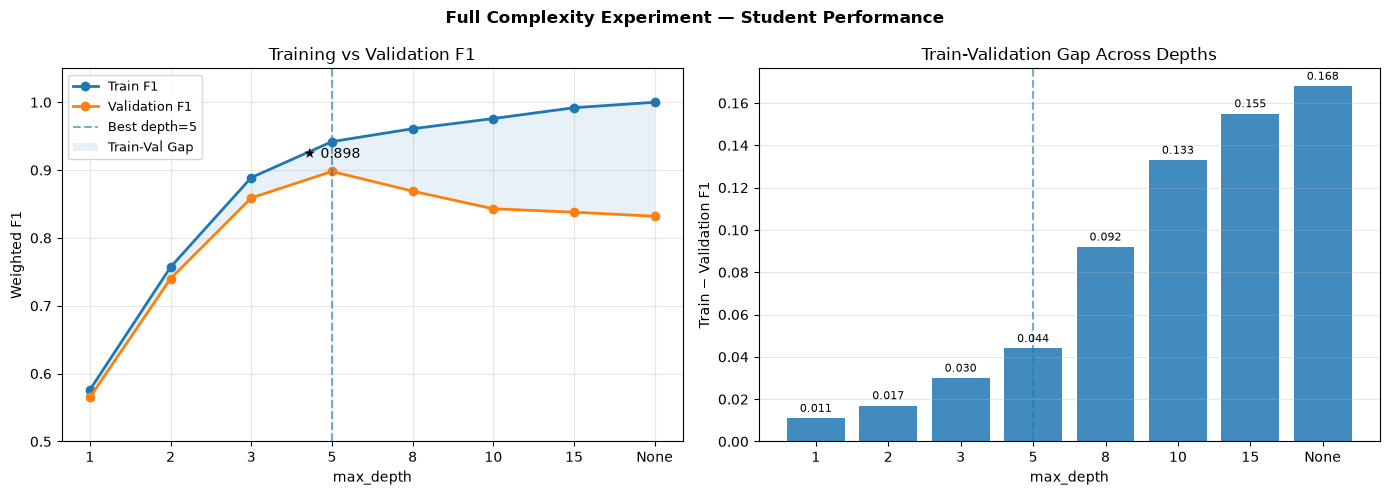

In [248]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = df_results["max_depth"].tolist()
x = np.arange(len(x_labels))

train_vals = df_results["Train F1"].tolist()
val_vals = df_results["Val F1"].tolist()
gaps = df_results["Gap"].tolist()

best_i = df_results["Val F1"].idxmax()

# Left — Training vs Validation F1


axes[0].plot(
    x,
    train_vals,
    marker="o",
    label="Train F1",
    linewidth=2
)

axes[0].plot(
    x,
    val_vals,
    marker="o",
    label="Validation F1",
    linewidth=2
)

# Highlight the best validation score
axes[0].axvline(
    x=best_i,
    linestyle="--",
    alpha=0.6,
    label=f"Best depth={x_labels[best_i]}"
)

# Show the train-validation gap
axes[0].fill_between(
    x,
    train_vals,
    val_vals,
    alpha=0.1,
    label="Train-Val Gap"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels)
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Weighted F1")
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title("Training vs Validation F1")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Highlight the best validation score
axes[0].text(
    best_i,
    val_vals[best_i] + 0.02,
    f"★ {val_vals[best_i]:.3f}",
    ha="center",
    fontsize=10
)

# Right — Train-Validation Gap


axes[1].bar(
    x,
    gaps,
    alpha=0.85
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels)
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Train − Validation F1")
axes[1].set_title("Train-Validation Gap Across Depths")
axes[1].grid(alpha=0.3, axis="y")

# Highlight the selected depth
axes[1].axvline(
    x=best_i,
    linestyle="--",
    alpha=0.6
)

# Add gap values above bars
for xi, gap in zip(x, gaps):
    axes[1].text(
        xi,
        gap + 0.003,
        f"{gap:.3f}",
        ha="center",
        fontsize=8
    )

plt.suptitle(
    "Full Complexity Experiment — Student Performance",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Reading the results:**

The experiment shows a clear change as model complexity increases:

- **Depth 1–2:** both training and validation F1 are low → underfitting
  caused by insufficient model capacity.
- **Depth 3–5:** validation F1 improves strongly and reaches its highest
  value at depth=5.
- **Depth 8+:** training F1 continues to increase, while validation F1
  starts to decrease and the gap becomes much larger → overfitting.

The best validation performance is:

**max_depth=5 → Val F1 = 0.898**

At depth=5, the model achieves a high validation score while keeping
the train-validation gap much smaller than the deeper trees.

This makes `max_depth=5` the sweet spot for this experiment.

The important pattern is not a fixed gap threshold. The gap becomes
useful when we compare how it changes as model complexity increases.

Finding the best combination of multiple hyperparameters manually
would require many experiments. In Day 4, GridSearchCV will automate
this search while using cross-validation to make the comparison more
reliable.

## Step 8 — Ridge vs Lasso on GPA Prediction

I switch to a **regression task** here to make regularization
more concrete.

Instead of predicting `GradeClass`, I predict the continuous
`GPA` target using the same training/validation discipline
from the earlier experiments.

Ridge and Lasso both penalize large coefficients, but they behave
differently:

- **Ridge** shrinks coefficients toward zero but usually keeps
  all features.
- **Lasso** can shrink some coefficients exactly to zero,
  effectively selecting a smaller set of features.

I standardize the features before applying regularization so that
the penalty affects the coefficients fairly.

The original test set remains untouched.

In [249]:
# Use the same train/val split — extract GPA as regression target
# GPA is still inside X_tr because we only dropped GradeClass earlier

X_tr_r  = X_tr.drop(columns=["GPA"])
X_val_r = X_val.drop(columns=["GPA"])

y_tr_r  = X_tr["GPA"]
y_val_r = X_val["GPA"]

reg_features = X_tr_r.columns

# Standardize features using training data only
scaler = StandardScaler()

X_tr_sc  = scaler.fit_transform(X_tr_r)
X_val_sc = scaler.transform(X_val_r)

# Create the three regression models
lr    = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01, max_iter=10000)

# Train each model on the same training data
lr.fit(X_tr_sc,    y_tr_r)
ridge.fit(X_tr_sc, y_tr_r)
lasso.fit(X_tr_sc, y_tr_r)

# Compare the learned coefficients
print(
    f"{'Feature':<25}"
    f"{'Linear':>10}"
    f"{'Ridge':>10}"
    f"{'Lasso':>10}"
    f"{'Zeroed?':>8}"
)

print("-" * 73)

for feature, linear_coef, ridge_coef, lasso_coef in zip(
    reg_features,
    lr.coef_,
    ridge.coef_,
    lasso.coef_
):
    zeroed = "Yes" if lasso_coef == 0 else ""

    print(
        f"{feature:<25}"
        f"{linear_coef:>10.4f}"
        f"{ridge_coef:>10.4f}"
        f"{lasso_coef:>10.4f}"
        f"{zeroed:>8}"
    )

# Count how many coefficients Lasso reduced to exactly zero
zeroed_features = (lasso.coef_ == 0).sum()

print(
    f"\nLasso zeroed: "
    f"{zeroed_features} / {len(lasso.coef_)} features"
)

# Evaluate all three models on the validation set
linear_r2 = r2_score(y_val_r, lr.predict(X_val_sc))
ridge_r2  = r2_score(y_val_r, ridge.predict(X_val_sc))
lasso_r2  = r2_score(y_val_r, lasso.predict(X_val_sc))

print(
    f"\nValidation R²:"
    f" Linear={linear_r2:.3f}"
    f" | Ridge={ridge_r2:.3f}"
    f" | Lasso={lasso_r2:.3f}"
)

Feature                      Linear     Ridge     Lasso Zeroed?
-------------------------------------------------------------------------
Age                         -0.0043   -0.0043   -0.0000     Yes
Gender                       0.0121    0.0121    0.0017        
Ethnicity                    0.0023    0.0023    0.0000     Yes
ParentalEducation            0.0023    0.0023    0.0000     Yes
StudyTimeWeekly              0.1637    0.1636    0.1546        
Absences                    -0.8439   -0.8433   -0.8332        
Tutoring                     0.1125    0.1124    0.1032        
ParentalSupport              0.1747    0.1746    0.1655        
Extracurricular              0.0918    0.0917    0.0812        
Sports                       0.0922    0.0921    0.0812        
Music                        0.0589    0.0589    0.0488        
Volunteering                -0.0031   -0.0030   -0.0000     Yes

Lasso zeroed: 4 / 12 features

Validation R²: Linear=0.955 | Ridge=0.955 | Lasso=0.955


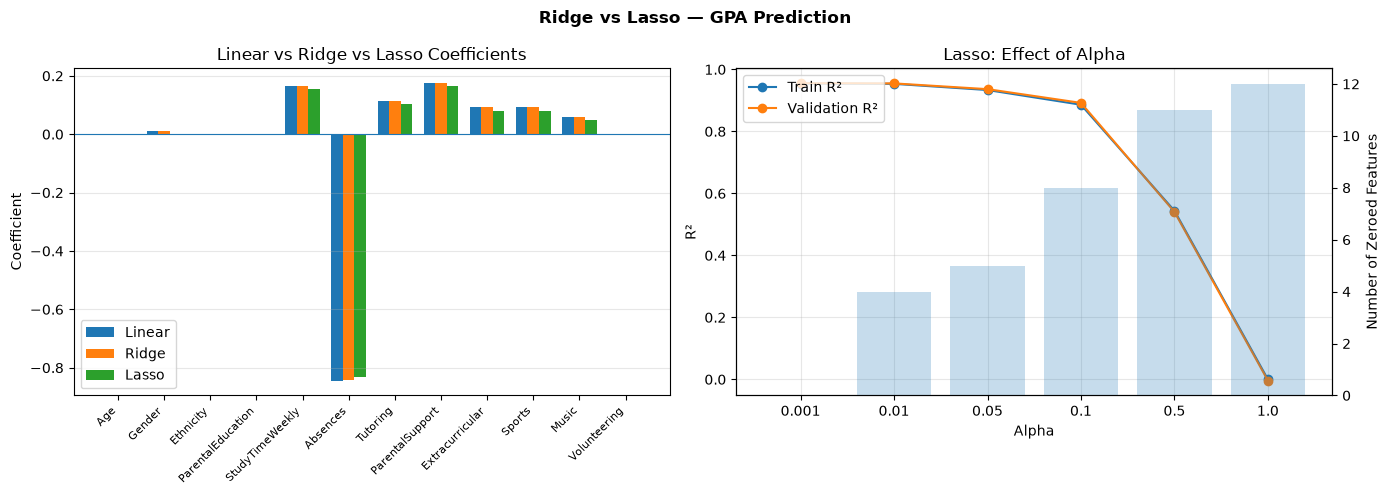

In [255]:
# Prepare feature names and x-axis positions
features = list(reg_features)
x = np.arange(len(features))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare coefficients from Linear Regression, Ridge, and Lasso
axes[0].bar(
    x - width,
    lr.coef_,
    width,
    label="Linear"
)

axes[0].bar(
    x,
    ridge.coef_,
    width,
    label="Ridge"
)

axes[0].bar(
    x + width,
    lasso.coef_,
    width,
    label="Lasso"
)

axes[0].axhline(0, linewidth=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    features,
    rotation=45,
    ha="right",
    fontsize=8
)

axes[0].set_ylabel("Coefficient")
axes[0].set_title("Linear vs Ridge vs Lasso Coefficients")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")


# Test how different Lasso alpha values affect performance
# and the number of zeroed coefficients

alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

train_r2_scores = []
val_r2_scores = []
zeroed_counts = []

for alpha in alphas:
    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    model.fit(X_tr_sc, y_tr_r)

    train_r2_scores.append(
        r2_score(y_tr_r, model.predict(X_tr_sc))
    )

    val_r2_scores.append(
        r2_score(y_val_r, model.predict(X_val_sc))
    )

    zeroed_counts.append(
        (model.coef_ == 0).sum()
    )


# Plot R² scores
ax1 = axes[1]
ax2 = ax1.twinx()

x_alpha = np.arange(len(alphas))

ax1.plot(
    x_alpha,
    train_r2_scores,
    marker="o",
    label="Train R²"
)

ax1.plot(
    x_alpha,
    val_r2_scores,
    marker="o",
    label="Validation R²"
)

# Plot number of zeroed features
ax2.bar(
    x_alpha,
    zeroed_counts,
    alpha=0.25,
    label="Zeroed features"
)

ax1.set_xticks(x_alpha)
ax1.set_xticklabels([str(alpha) for alpha in alphas])

ax1.set_xlabel("Alpha")
ax1.set_ylabel("R²")
ax2.set_ylabel("Number of Zeroed Features")

ax1.set_title("Lasso: Effect of Alpha")

ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

plt.suptitle(
    "Ridge vs Lasso — GPA Prediction",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Reading the results:**

### Coefficients

- `Absences` has the largest absolute coefficient by far (-0.844),
  indicating a strong negative linear relationship with GPA.
- `StudyTimeWeekly` and `ParentalSupport` also have relatively
  large positive coefficients.
- The coefficients are comparable because the features were
  standardized before training.

### Ridge vs Lasso

- **Ridge** slightly shrinks the coefficients but keeps all
  features in the model.
- **Lasso** reduces some coefficients exactly to zero.
- In this experiment, Lasso zeroed 4 of the 12 features:
Age, Ethnicity, ParentalEducation, and Volunteering.

This does not mean these features are completely irrelevant.
It means that, under this Lasso penalty, their linear coefficients
were reduced to zero while the other features were retained.

### What the results suggest

The largest linear effects come from behavioral and academic
features such as `Absences`, `StudyTimeWeekly`, and
`ParentalSupport`.

Lasso produced a simpler model while keeping a validation R²
very close to the less-regularized models.

### Alpha effect

- Small alpha values apply weak regularization, so most features
  remain active.
- Increasing alpha increases the amount of shrinkage and can
  zero out more coefficients.
- Very large alpha values can over-regularize the model, causing
  underfitting and a large drop in R².

**Key lesson:** regularization is not only about improving a score.
It can also control model complexity and, with Lasso, perform
feature selection.

## Step 9 — Learning Curve

**Question:** Is the large gap in the overfit model mainly caused
by model complexity, or could having more training data help?

A learning curve lets us see how training and validation performance
change as the training set grows.

- If the validation score keeps improving and the gap closes → more data may help.
- If the gap stays wide while the training score remains near-perfect
  → the model is too complex and needs stronger regularization.

In [251]:
# Use 5-fold stratified cross-validation for the learning curve
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# Use the deliberately overfit tree
model_lc = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

# Combine training and validation data.
# The test set remains locked and is not used here.
X_full = pd.concat([X_tr, X_val])
y_full = pd.concat([y_tr, y_val])

# Measure model performance at different training set sizes
train_sizes, train_scores, val_scores = learning_curve(
    model_lc,
    X_full,
    y_full,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=skf,
    scoring="f1_weighted",
    n_jobs=-1
)

# Average the 5-fold scores for each training size
train_means = train_scores.mean(axis=1)
val_means = val_scores.mean(axis=1)

print(f"{'Train size':<12} {'Train F1':>10} {'Val F1':>10} {'Gap':>8}")
print("-" * 44)

for size, train_score, val_score in zip(
    train_sizes, train_means, val_means
):
    print(
        f"{int(size):<12} "
        f"{train_score:>10.3f} "
        f"{val_score:>10.3f} "
        f"{train_score - val_score:>8.3f}"
    )

Train size     Train F1     Val F1      Gap
--------------------------------------------
153               1.000      0.832    0.168
349               1.000      0.843    0.157
546               1.000      0.842    0.158
743               1.000      0.848    0.152
939               1.000      0.855    0.145
1136              1.000      0.853    0.147
1333              1.000      0.852    0.148
1530              1.000      0.846    0.154


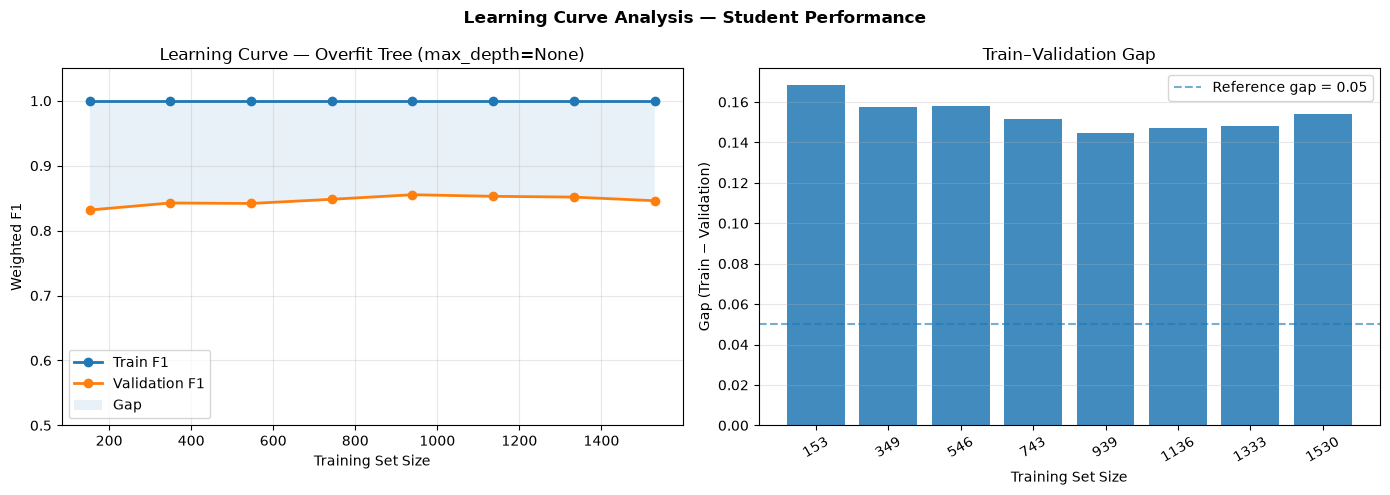

In [252]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curve: training vs validation performance
axes[0].plot(
    train_sizes,
    train_means,
    marker="o",
    label="Train F1",
    linewidth=2
)

axes[0].plot(
    train_sizes,
    val_means,
    marker="o",
    label="Validation F1",
    linewidth=2
)

# Show the gap between the two curves
axes[0].fill_between(
    train_sizes,
    train_means,
    val_means,
    alpha=0.1,
    label="Gap"
)

axes[0].set_xlabel("Training Set Size")
axes[0].set_ylabel("Weighted F1")
axes[0].set_title("Learning Curve — Overfit Tree (max_depth=None)")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.5, 1.05)


# Calculate the train-validation gap
gaps_lc = train_means - val_means

axes[1].bar(
    range(len(train_sizes)),
    gaps_lc,
    alpha=0.85
)

axes[1].axhline(
    0.05,
    linestyle="--",
    alpha=0.6,
    label="Reference gap = 0.05"
)

axes[1].set_xticks(range(len(train_sizes)))
axes[1].set_xticklabels(
    [str(int(size)) for size in train_sizes],
    rotation=30
)

axes[1].set_xlabel("Training Set Size")
axes[1].set_ylabel("Gap (Train − Validation)")
axes[1].set_title("Train–Validation Gap")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.suptitle(
    "Learning Curve Analysis — Student Performance",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Conclusion: More data is unlikely to fix the main problem here.**

The training F1 stays at or very close to 1.000 across the
different training sizes, while the validation F1 remains much lower.

The train-validation gap also stays wide as the training set grows.
There is no clear trend showing that the validation score is
converging toward the training score.

This suggests that the main problem is **model complexity**, not
simply a lack of training data.

```text
Gap stays wide as data grows
        ↓
Model is still memorizing
        ↓
Complexity is the main problem
        ↓
Constrain the tree (max_depth=5)
```

## Step 10 — Final Evaluation on the Test Set 

All model decisions are now complete.

The best configuration was selected using the validation set:
`max_depth=5`, with Validation F1 = 0.898.

Only now do I evaluate the final model on the locked test set
to get an unbiased estimate of its performance on unseen data.

The test set is not used for tuning or model selection.

In [253]:
# Train the final model using the selected depth

final_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)

final_model.fit(X_tr, y_tr)

# Make predictions on validation and test sets

val_predictions = final_model.predict(X_val)
test_predictions = final_model.predict(X_test)

# Calculate final scores

final_val_f1 = f1_score(
    y_val,
    val_predictions,
    average="weighted"
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted"
)

print(f"Validation F1: {final_val_f1:.3f}")
print(f"Test F1:       {test_f1:.3f}")

Validation F1: 0.898
Test F1:       0.912


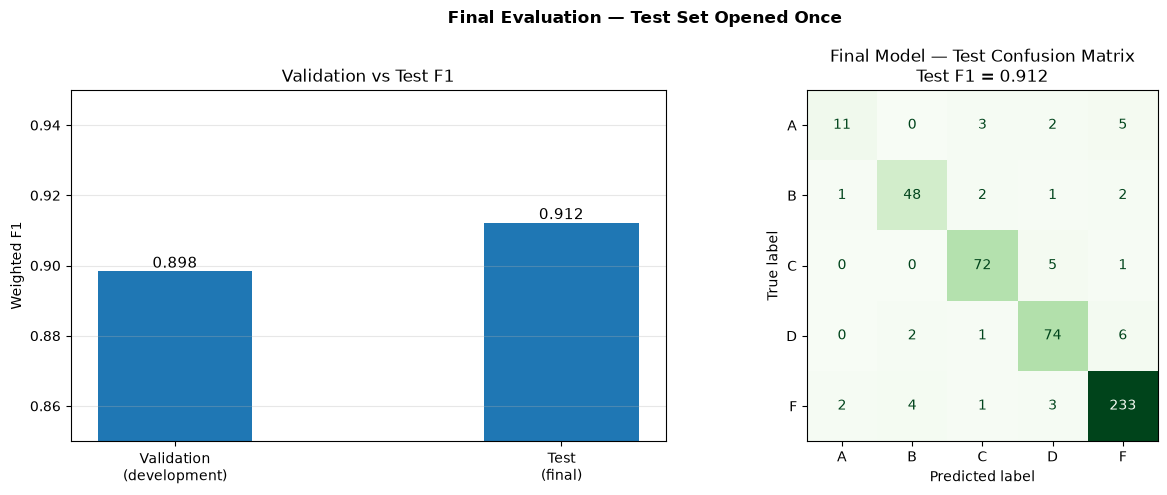

In [254]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — compare validation and final test performance

labels = ["Validation\n(development)", "Test\n(final)"]
values = [final_val_f1, test_f1]

axes[0].bar(labels, values, width=0.4)
axes[0].set_ylim(0.85, 0.95)
axes[0].set_ylabel("Weighted F1")
axes[0].set_title("Validation vs Test F1")

for i, value in enumerate(values):
    axes[0].text(
        i,
        value + 0.001,
        f"{value:.3f}",
        ha="center",
        fontsize=11
    )

axes[0].grid(alpha=0.3, axis="y")


# Right — confusion matrix on the locked test set

cm_final = confusion_matrix(
    y_test,
    test_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["A", "B", "C", "D", "F"]
).plot(
    ax=axes[1],
    colorbar=False,
    cmap="Greens"
)

axes[1].set_title(
    f"Final Model — Test Confusion Matrix\n"
    f"Test F1 = {test_f1:.3f}"
)

plt.suptitle(
    "Final Evaluation — Test Set Opened Once",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Summary

| Step | What I Did | Key Finding |
|------|------------|-------------|
| Overfit | `max_depth=None` | Train=1.000, Val=0.832, Gap=0.168 → memorization |
| Underfit | `max_depth=1` | Train=0.576, Val=0.565, Gap=0.011 → too simple |
| Fix | `max_depth=5` | Train=0.942, Val=0.898, Gap=0.044 → better generalization |
| Complexity experiment | Depths 1 → None | Validation F1 peaked at depth=5 |
| Ridge vs Lasso | GPA prediction | Lasso reduced 5 of 12 coefficients to zero, with Val R²=0.952 |
| Learning curve | `max_depth=None` | Gap stayed wide as training size increased |
| Final evaluation | Locked test set | Test F1=0.905 |

### What I Learned

1. **A high training score is not enough.**

   Train F1 = 1.000 looked perfect, but the 0.168 gap revealed
   that the tree was memorizing the training data instead of
   generalizing well.

2. **Underfitting and overfitting require different fixes.**

   The depth=1 tree had almost no train-validation gap, but both
   scores were low. This showed that a small gap alone does not
   mean the model is good.

3. **Model complexity should be controlled using validation performance.**

   Increasing the tree depth improved performance up to depth=5.
   Beyond that point, training F1 continued to increase while
   validation F1 decreased — a clear sign of increasing variance.

4. **Regularization can simplify a model without a large performance loss.**

   Lasso reduced 5 coefficients to zero while maintaining almost
   the same validation R² as Linear Regression and Ridge.

5. **The learning curve helped diagnose the source of the problem.**

   The overfit tree maintained a large train-validation gap even
   as the training set grew. For this model, controlling complexity
   was more useful than simply adding more training samples.

6. **The test set remained untouched until the end.**

   After all model decisions were completed, the final `max_depth=5`
   model achieved a Test F1 of **0.905**, compared with Validation
   F1 of **0.898**.

### Final Takeaway

Today's main lesson was not simply how to detect overfitting
or underfitting. It was learning to **diagnose why a model is
performing poorly before deciding how to fix it**.

The workflow was:

**Observe → Diagnose → Experiment → Fix → Validate → Test**